<a href="https://colab.research.google.com/github/Isannali/Semantic-Segmentation-From-Scratch/blob/main/Semantic_Segmentations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="1ZSjOsWu1xb3nomtGrm0")
project = rf.workspace("ihsans-workspace-zi8ij").project("building-facade-segmentation-original-4kwd5")
version = project.version(2)
dataset = version.download("png-mask-semantic")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
!pip install -q segmentation-models-pytorch
!pip install -q torchmetrics
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
# Untuk Image Augmentation, lebih banyak variasi augmentasi dibandingkan torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import matplotlib.pyplot as plt
import cv2
# Untuk calculasi loss
import segmentation_models_pytorch as smp
import torchmetrics
from torch.utils.data import Dataset


In [3]:
class Building(Dataset):
  def __init__(self,
               image_folder_path, #  inputan image RGB
               mask_folder_path, # Gambar label masking Ground Truthnya
               transforms=None):
    self.images_folder = image_folder_path
    self.masks_folder = mask_folder_path
    self.transforms = transforms

  def __len__(self):
    return len(self.images_folder)

  def __getitem__(self, index):
    # Input image = .jpg
    image_path=self.images_folder[index]
    # Input mask = .png
    mask_path = self.masks_folder[index]
    #membaca gambar
    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path)
    # Ubah ke RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = mask[:,:,2]

    if self.transforms is not None:
      augmented = self.transforms(image=image, mask=mask)
      image = augmented['image']
      mask = augmented['mask']

    return image, mask.unsqueeze(0)

In [4]:
transforms_train = A.Compose([

    A.Resize(128,128),# Resize gambarnya
    A.Normalize(), # biar pixelnya 0-1
    ToTensorV2() # kita ubah formatnya ke tensor
])
transforms_valid = A.Compose([

    A.Resize(128,128),# Resize gambarnya
    A.Normalize(), # biar pixelnya 0-1
    ToTensorV2() # kita ubah formatnya ke tensor
])
transforms_test = A.Compose([

    A.Resize(128,128),# Resize gambarnya
    A.Normalize(), # biar pixelnya 0-1
    ToTensorV2() # kita ubah formatnya ke tensor
])


In [5]:
import glob
Train_path="/content/building-facade-segmentation-original-2/train"
Valid_path="/content/building-facade-segmentation-original-2/valid"
Test_path="/content/building-facade-segmentation-original-2/test"
train_images=sorted(glob.glob(os.path.join(Train_path,"*.jpg")))
train_masks=sorted(glob.glob(os.path.join(Train_path,"*.png")))
valid_images= sorted(glob.glob(os.path.join(Valid_path,"*.jpg")))
valid_masks= sorted(glob.glob(os.path.join(Valid_path,"*.png")))
test_images = sorted(glob.glob(os.path.join(Test_path,"*.jpg")))
test_masks = sorted(glob.glob(os.path.join(Test_path,"*.png")))

In [6]:
data_train = Building(train_images, train_masks, transforms=transforms_train)
data_valid = Building(valid_images, valid_masks, transforms=transforms_valid)
data_test = Building(test_images, test_masks, transforms=transforms_test)

In [7]:
data_train[0][0].shape, data_train[0][1].shape, data_train[0][1].unique()

(torch.Size([3, 128, 128]),
 torch.Size([1, 128, 128]),
 tensor([ 0,  1,  2,  3,  4,  7,  9, 10], dtype=torch.uint8))

In [8]:
all_class = []
for i in range(len(data_train)):
  all_class.extend(data_train[i][1].unique().tolist())
all_class = list(set(all_class))

In [9]:
print(all_class)
print(len(data_train))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
357


Model Architecture


In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3,stride= 1,padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3,stride= 1,padding= 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [11]:
class UNET(nn.Module):
    def __init__(
            self, in_channels=3, out_channels=11, features=[64, 128, 256, 512],
    ):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # doblemconv, dobleconv..
        # Down part of UNET
        for feature in features:
            # 0: 3 -> 64
            # 1: 64 -> 128
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        #upsam, doubleconv, up, ..
        # Up part of UNET
        for feature in reversed(features):
            self.ups.append(#0
                nn.ConvTranspose2d(
                    feature*2, feature, kernel_size=2, stride=2,
                )
            )
            self.ups.append(DoubleConv(feature*2, feature))#1

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            # ngesave informasi
            skip_connections.append(x)
            # masuk maxpooling
            x = self.pool(x)

        # bagian yang paling kecil sbg transisi ke upsample
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1] # reversed(skip_connections)

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

Engine

In [20]:
!pip install --upgrade torchmetrics
import torch
import torchmetrics.classification # Add this import for MulticlassF1Score

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0

    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        # kita reset gradient
        optimizer.zero_grad()

        # kita forward
        output = model(data)
        # Kita calculate loss -> loss: Dice Score
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return train_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    eval_loss = 0.0
    f1_score_total = 0.0 # Renamed dice_score to f1_score_total for clarity as it's F1 score now
    # Dynamically set num_classes based on the 'all_class' variable
    f1_score_function = torchmetrics.classification.MulticlassF1Score(num_classes=len(all_class), average='micro').to(device)

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(dataloader):
            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target.long())
            eval_loss += loss.item()

            # Squeeze the target to remove the channel dimension [B, 1, H, W] -> [B, H, W]
            f1_score_total += f1_score_function(output, target.squeeze(1).long())

    return eval_loss / len(dataloader), f1_score_total / len(dataloader)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNET()

model.to(device)

UNET(
  (ups): ModuleList(
    (0): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), p

In [22]:
def train(model, train_datasets, valid_datasets):
  train_dataloader = torch.utils.data.DataLoader(train_datasets, 8, True, num_workers=2)
  valid_dataloader = torch.utils.data.DataLoader(valid_datasets, 8, False, num_workers=2)

  device = "cuda" if torch.cuda.is_available() else "cpu"

  criterion = smp.losses.DiceLoss(mode='multiclass')
  optimizer = torch.optim.Adam(model.parameters(), 1e-3)

  num_epochs = 10

  best_eval_loss = float('inf')

  for epoch in range(num_epochs):
      # Training
      train_loss = train_epoch(model, train_dataloader, criterion, optimizer, device)

      # Validation
      valid_loss, dice_score = evaluate(model, valid_dataloader, criterion, device)

      # Print results
      print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Eval Loss = {valid_loss:.4f}, Dice Score = {dice_score:.4f}")
      # print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Eval Loss = {eval_loss:.4f}")

      if valid_loss < best_eval_loss:
        best_eval_loss = valid_loss
        torch.save(model.state_dict(), 'best.pt')

In [23]:
train(model,data_train, data_valid)

Epoch 1: Train Loss = 0.8076, Eval Loss = 0.7351, Dice Score = 0.5340
Epoch 2: Train Loss = 0.7384, Eval Loss = 0.7145, Dice Score = 0.5104
Epoch 3: Train Loss = 0.6853, Eval Loss = 0.6771, Dice Score = 0.6334
Epoch 4: Train Loss = 0.6648, Eval Loss = 0.6564, Dice Score = 0.6311
Epoch 5: Train Loss = 0.6617, Eval Loss = 0.6444, Dice Score = 0.6386
Epoch 6: Train Loss = 0.6360, Eval Loss = 0.6456, Dice Score = 0.5883
Epoch 7: Train Loss = 0.6299, Eval Loss = 0.6394, Dice Score = 0.6953
Epoch 8: Train Loss = 0.6153, Eval Loss = 0.6275, Dice Score = 0.6536
Epoch 9: Train Loss = 0.6104, Eval Loss = 0.6147, Dice Score = 0.6708
Epoch 10: Train Loss = 0.5922, Eval Loss = 0.6116, Dice Score = 0.6483


In [25]:
sample = data_test[0]
x = sample[0].to(device).unsqueeze(0) # Move input to the correct device
out = model(x)

In [26]:
out


tensor([[[[  2.0648,   4.1900,   4.8221,  ...,   0.5417,   0.6083,  -0.4120],
          [  3.3269,   5.0132,   5.5554,  ...,  -0.1921,   0.1620,  -0.3258],
          [  4.0591,   5.6534,   5.9508,  ...,   0.0626,   0.4227,  -0.1035],
          ...,
          [ -3.5812,  -4.6875,  -5.1237,  ...,  -5.5439,  -4.5259,  -3.9547],
          [ -3.5801,  -4.6503,  -5.1612,  ...,  -5.2618,  -4.4258,  -3.9998],
          [ -3.8387,  -4.6622,  -5.2320,  ...,  -4.7355,  -4.2160,  -4.0830]],

         [[ -1.5697,  -1.3836,  -1.5909,  ...,  -0.5277,  -0.4397,  -1.1211],
          [ -1.3726,  -1.2162,  -1.4563,  ...,   0.2482,   0.2367,  -0.7381],
          [ -1.2840,  -1.3249,  -1.5270,  ...,   0.6581,   0.6378,  -0.3576],
          ...,
          [ -6.2920, -10.0196, -12.1850,  ..., -13.9286, -10.6253,  -6.1374],
          [ -5.9317,  -9.3339, -11.3131,  ..., -12.8528,  -9.7597,  -5.7479],
          [ -5.7162,  -8.7985, -10.4589,  ..., -10.8046,  -8.3495,  -5.1593]],

         [[ -5.9583,  -4.4900,

In [27]:
out.shape

torch.Size([1, 11, 128, 128])

In [28]:
def common_encoding(one_hot):
    num_classes, height, width = one_hot.shape
    common_mask = torch.zeros((height, width), dtype=torch.int64)

    for class_idx in range(1, num_classes):
        class_mask = (one_hot[class_idx] == 1).nonzero(as_tuple=True)
        common_mask[class_mask] = class_idx

    return common_mask

In [29]:
def rgb_encoding(common_mask):
    color_dict = {
        0: (255, 0, 0),     # Red
        1: (0, 255, 0),     # Green
        2: (0, 0, 255),     # Blue
        3: (255, 255, 0),   # Yellow
        4: (255, 0, 255),   # Magenta
        5: (0, 255, 255),   # Cyan
        6: (128, 0, 0),     # Maroon
        7: (0, 128, 0),     # Dark Green
        8: (0, 0, 128),     # Navy
        9: (128, 128, 0),  # Olive
        10: (128, 0, 128),  # Purple
        11: (0, 128, 128)   # Teal
    }

    num_classes = torch.max(common_mask).item() + 1
    rgb_mask = torch.zeros((3, common_mask.shape[0], common_mask.shape[1]), dtype=torch.uint8)

    for class_idx in range(1, 11):
        if class_idx in color_dict:
            class_color = color_dict[class_idx]
            class_mask = (common_mask == class_idx)

            for channel in range(3):
                rgb_mask[channel][class_mask] = class_color[channel]

    return rgb_mask.permute(1, 2, 0)

In [30]:
def postprocess(out, thr=0.6):
  out = out.squeeze(0)
  out = torch.softmax(out, 0)
  out[out>=thr] = 1
  out = common_encoding(out)
  out = rgb_encoding(out)
  return out

In [31]:
postprocess(out)

tensor([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [255, 255,   0],
         [255, 255,   0],
         [255, 255,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [255, 255,   0],
         [255, 255,   0],
         [255, 255,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [255, 255,   0],
         [255, 255,   0],
         [255, 255,   0]],

        ...,

        [[  0, 128,   0],
         [  0, 128,   0],
         [  0, 128,   0],
         ...,
         [255,   0, 255],
         [255,   0, 255],
         [255,   0, 255]],

        [[  0, 128,   0],
         [  0, 128,   0],
         [  0, 128,   0],
         ...,
         [255,   0, 255],
         [255,   0, 255],
         [  0,   0,   0]],

        [[  0, 128,   0],
         [  0, 128,   0],
         [  0, 128,   0],
         ...,
         [255,   0, 255],
        

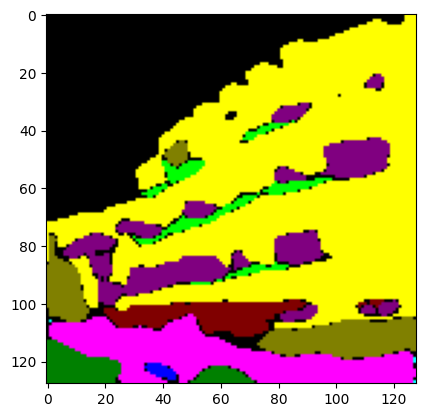

In [32]:
out2 = postprocess(out)
plt.imshow(out2)
plt.show()

tensor([0, 2, 3, 4, 7, 9], dtype=torch.uint8)


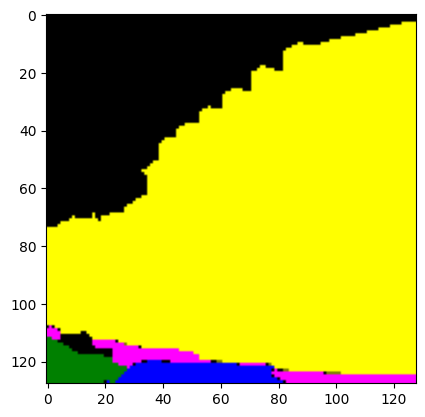

In [33]:
target = sample[1]
print(target.unique())
target = target.squeeze(0)
target = rgb_encoding(target)
plt.imshow(target)
plt.show()

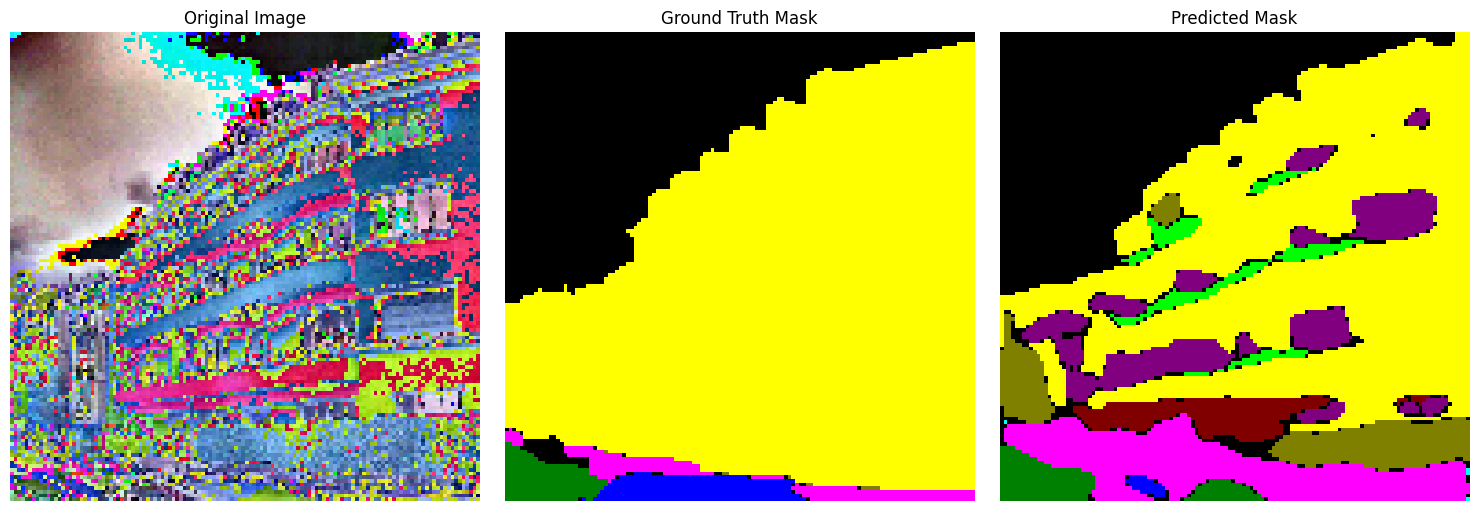

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Get the original image (it's already on the CPU from data_test[0])
original_image_tensor = sample[0].cpu().numpy()

# Denormalize the image for display
# Assuming Normalize() was applied with mean=0.0 and std=1.0 for simplicity or you know the actual values.
# If you used specific mean/std in A.Normalize(), you'll need to reverse them here.
# For now, we'll just reorder channels and clip to 0-1 range if needed.
original_image = np.transpose(original_image_tensor, (1, 2, 0)) # Change from C, H, W to H, W, C
original_image = (original_image * 255).astype(np.uint8) # Assuming it's in 0-1 range from Normalize

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Original Image
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Plot Ground Truth Mask (target is already processed by rgb_encoding in the previous cell)
axes[1].imshow(target)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

# Plot Predicted Mask (out2 is already processed by postprocess in the previous cell)
axes[2].imshow(out2.cpu().numpy()) # Ensure out2 is on CPU for matplotlib
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()